In [ ]:
"""DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING"""

In [ ]:
### Data Exploration and Preprocessing

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('adult_with_headers12.csv')

# Display first 5 rows
print("First 5 Rows of Dataset", df.head())

# Basic information about data types and non-null counts
print("Dataset Information:")
print(df.info())

# Summary statistics for all columns
print("Summary Statistics:")
print(df.describe(include='all'))

# Checking missing values
print("Missing Values in Each Column:")
print(df.isnull().sum())

# Data types of all columns
print("Data Types of Columns:")
print(df.dtypes)


First 5 Rows of Dataset:
    age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0             

In [ ]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv('adult_with_headers12.csv')

# Replace '?' with np.nan
df.replace('?', np.nan, inplace=True)

# Check missing values
print("Missing Values:", df.isnull().sum())



# Impute missing categorical values with mode
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

#  Impute missing numerical values with median
for col in df.select_dtypes(include='number').columns:
    df[col].fillna(df[col].median(), inplace=True)

# Final check
print("Missing Values after Imputation:", df.isnull().sum())


Missing Values:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64
Missing Values after Imputation:
 age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


/tmp/ipython-input-11-866170866.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipython-input-11-866170866.py:21: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', t

In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load dataset
df = pd.read_csv('adult_with_headers12.csv')

# Identify numerical columns
numerical_features = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

# Initialize scalers
standard_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

# Apply Standard Scaling
standard_scaled = standard_scaler.fit_transform(df[numerical_features])
standard_scaled_df = pd.DataFrame(standard_scaled, columns=[col + '_std' for col in numerical_features])

# Apply Min-Max Scaling
minmax_scaled = minmax_scaler.fit_transform(df[numerical_features])
minmax_scaled_df = pd.DataFrame(minmax_scaled, columns=[col + '_minmax' for col in numerical_features])

# Concatenate scaled features to original dataframe
df_scaled = pd.concat([df, standard_scaled_df, minmax_scaled_df], axis=1)

# Show first 5 rows of scaled dataframe
print(df_scaled.head())


   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   ...  education_num_std  capital_gain_std  capital_loss_std  \
0  ...           1.134739          0.148453          -0.21666   
1  ...    

In [ ]:
"""Standard Scaling transforms features to have a mean = 0 and standard deviation = 1.

Min-Max Scaling scales features to a [0, 1] range."""

In [ ]:
"""When to Use Standard Scaling (Z-score normalization)
Definition: Transforms data to have mean = 0 and standard deviation = 1.

Preferred When:

Features follow a normal  distribution.

Algorithms assume data centered around 0 or rely on distance measures that are sensitive to variances.

Examples of such algorithms:

Linear Regression

Logistic Regression

Support Vector Machines (SVM)

Principal Component Analysis (PCA)

K-Means Clustering

Why: It prevents features with larger magnitudes from dominating the model’s performance.

 When to Use Min-Max Scaling
Definition: Transforms data into a 0 to 1 range.

Preferred When:

Features do not follow a normal distribution.

Algorithms that are sensitive to the scale or where absolute magnitudes of values impact the model.

Examples of such algorithms:

Neural Networks

K-Nearest Neighbors (KNN)

Gradient Descent-based methods

Decision Trees (optional, but sometimes beneficial for consistency)

Why: It ensures that all features contribute equally within the same range, avoiding bias from features with larger scales."""



In [ ]:
###  Encoding Techniques

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns in df_scaled
categorical_columns = df_scaled.select_dtypes(include='object').columns

# Separate columns based on unique value count
one_hot_cols = [col for col in categorical_columns if df_scaled[col].nunique() < 5]
label_enc_cols = [col for col in categorical_columns if df_scaled[col].nunique() >= 5]

print("One-Hot Encoding will be applied to:", one_hot_cols)
print("Label Encoding will be applied to:", label_enc_cols)

# Apply One-Hot Encoding
df_one_hot = pd.get_dummies(df_scaled[one_hot_cols], prefix=one_hot_cols)

# Apply Label Encoding
label_encoder = LabelEncoder()
df_label_enc = df_scaled[label_enc_cols].apply(lambda col: label_encoder.fit_transform(col))

# Combine all encoded data with the remaining features (numerical + scaled features)
df_encoded_scaled = pd.concat([df_scaled.drop(columns=categorical_columns), df_one_hot, df_label_enc], axis=1)

# Display the final encoded dataframe
print(df_encoded_scaled.head())


One-Hot Encoding will be applied to: ['sex', 'income']
Label Encoding will be applied to: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week  \
0   39   77516             13          2174             0              40   
1   50   83311             13             0             0              13   
2   38  215646              9             0             0              40   
3   53  234721              7             0             0              40   
4   28  338409             13             0             0              40   

    age_std  fnlwgt_std  education_num_std  capital_gain_std  ...  sex_ Male  \
0  0.030671   -1.063611           1.134739          0.148453  ...       True   
1  0.837109   -1.008707           1.134739         -0.145920  ...       True   
2 -0.042642    0.245079          -0.420060         -0.145920  ...       True   
3  1.057047    0.425801   

In [ ]:
"""Summary
One-Hot Encoding for low-cardinality categorical data (less than 5 unique values).

 Label Encoding when dealing with high-cardinality categorical data (5 or more unique values).

Choice depends on the model and whether the data is ordinal or nominal."""

In [ ]:
"""| Encoding Type        | Pros                                                                          | Cons                                                                                                             |
   | -------------------- | --------------------------------------------------------------------------    | ---------------------------------------------------------------------------------------------------------------- |
   | One-Hot Encoding     | - No ordinal relationship assumed    and - Works well with tree-based models  | - Increases dimensionality    and - Risk of curse of dimensionality                                              |
   | Label Encoding       | - Simple and memory efficient  and  - Keeps data compact                      | - Introduces ordinal relationship, even if not present      and - Can mislead distance-based algorithms like KNN |"""


In [ ]:
### Feature Engineering

In [ ]:
import pandas as pd
import numpy as np



df_fe = df_encoded_scaled.copy()

#  1. New Feature: Capital Net Gain
df_fe['capital_net_gain'] = df_fe['capital_gain'] - df_fe['capital_loss']

# 2. New Feature: Age Group (Categorizing age into bins)
df_fe['age_group'] = pd.cut(df_scaled['age'],
                            bins=[16, 25, 45, 65, 100],
                            labels=['Young', 'Adult', 'Senior Adult', 'Senior Citizen'])

#  3. Log Transformation on Skewed Feature: capital_gain
df_fe['capital_gain_log'] = df_scaled['capital_gain'].apply(lambda x: np.log1p(x))  # log1p handles 0 safely

# Encode age_group (since it's categorical)
df_fe['age_group_encoded'] = df_fe['age_group'].cat.codes

# Final Preview of New Features
print(df_fe[['capital_net_gain', 'age_group', 'age_group_encoded', 'capital_gain', 'capital_gain_log']].head())


   capital_net_gain     age_group  age_group_encoded  capital_gain  \
0              2174         Adult                  1          2174   
1                 0  Senior Adult                  2             0   
2                 0         Adult                  1             0   
3                 0  Senior Adult                  2             0   
4                 0         Adult                  1             0   

   capital_gain_log  
0          7.684784  
1          0.000000  
2          0.000000  
3          0.000000  
4          0.000000  


In [ ]:
"""Feature: capital_net_gain

Rationale: Both capital_gain and capital_loss individually describe parts of financial behavior, but combining them gives the net financial benefit or loss, which is more informative for predicting income. A person with higher net gains might have a higher income category.

Feature: age_group

Rationale: Instead of using raw age, grouping into categories like Young, Adult, Senior Adult, Senior Citizen captures differences in income patterns across life stages. For example, adults are more likely to earn more than young people, while senior citizens might be retired.

Transformation: Log on capital_gain

Rationale: The capital_gain feature is highly skewed — most people have zero gain, and a few have very high values. Skewed data can mislead many algorithms. Applying the log transformation reduces skewness, making the data more normalized and suitable for algorithms that assume normality (like linear models).

Transformation on Skewed Data
Feature Transformed: capital_gain

Transformation: Log Transformation using np.log1p

Why: capital_gain is heavily skewed (many zero values, few very high values). Log transformation reduces skewness, normalizing the feature for better model performance in algorithms sensitive to distribution, like Linear Models or KNN."""

In [ ]:
### Feature Selection

In [ ]:
from sklearn.ensemble import IsolationForest
import pandas as pd

# Apply Isolation Forest on numerical features
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outliers = iso_forest.fit_predict(df_fe.select_dtypes(include='number'))

# Mark outliers
df_fe['outlier'] = outliers

# Remove outliers (-1 are outliers)
df_no_outliers = df_fe[df_fe['outlier'] != -1].drop(columns='outlier')

print("Shape after outlier removal:", df_no_outliers.shape)


Shape after outlier removal: (32235, 33)


In [ ]:
from google.colab import files
uploaded = files.upload()


Saving adult_with_headers12.csv to adult_with_headers12.csv


In [ ]:
import pandas as pd


df = pd.read_csv('adult_with_headers12.csv')

# Preview the first few rows
df.head()


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


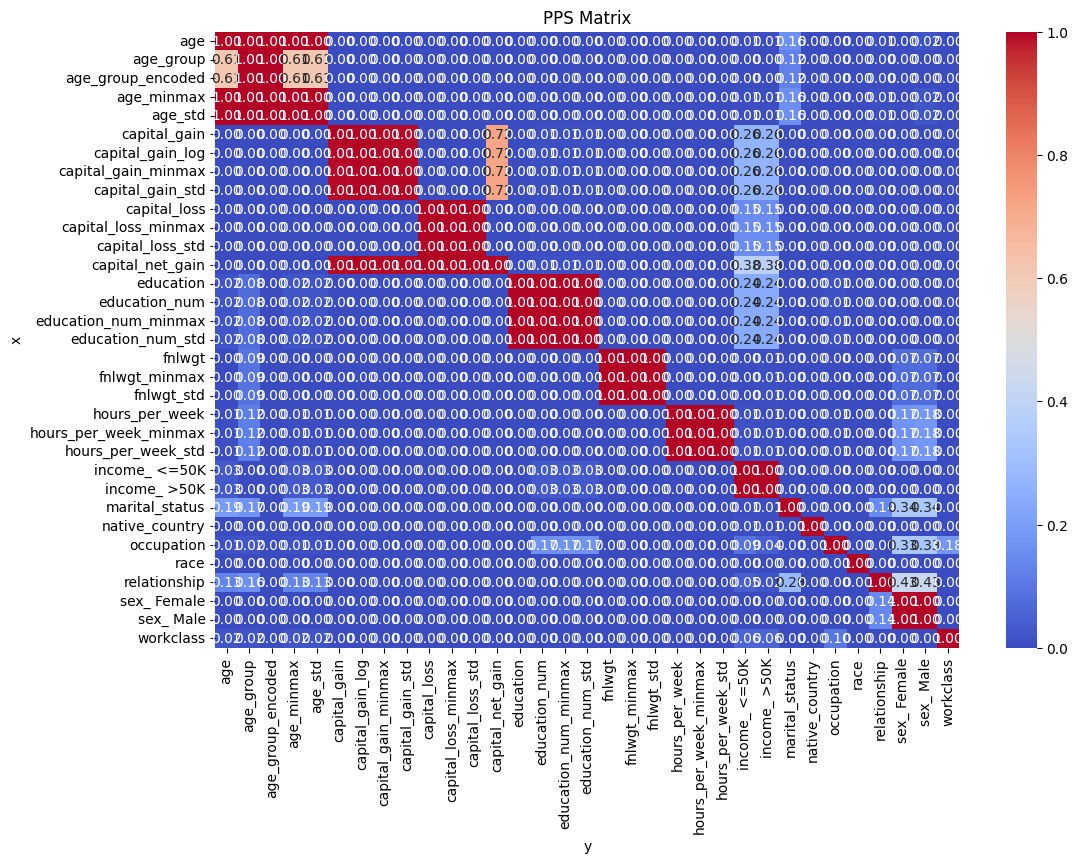

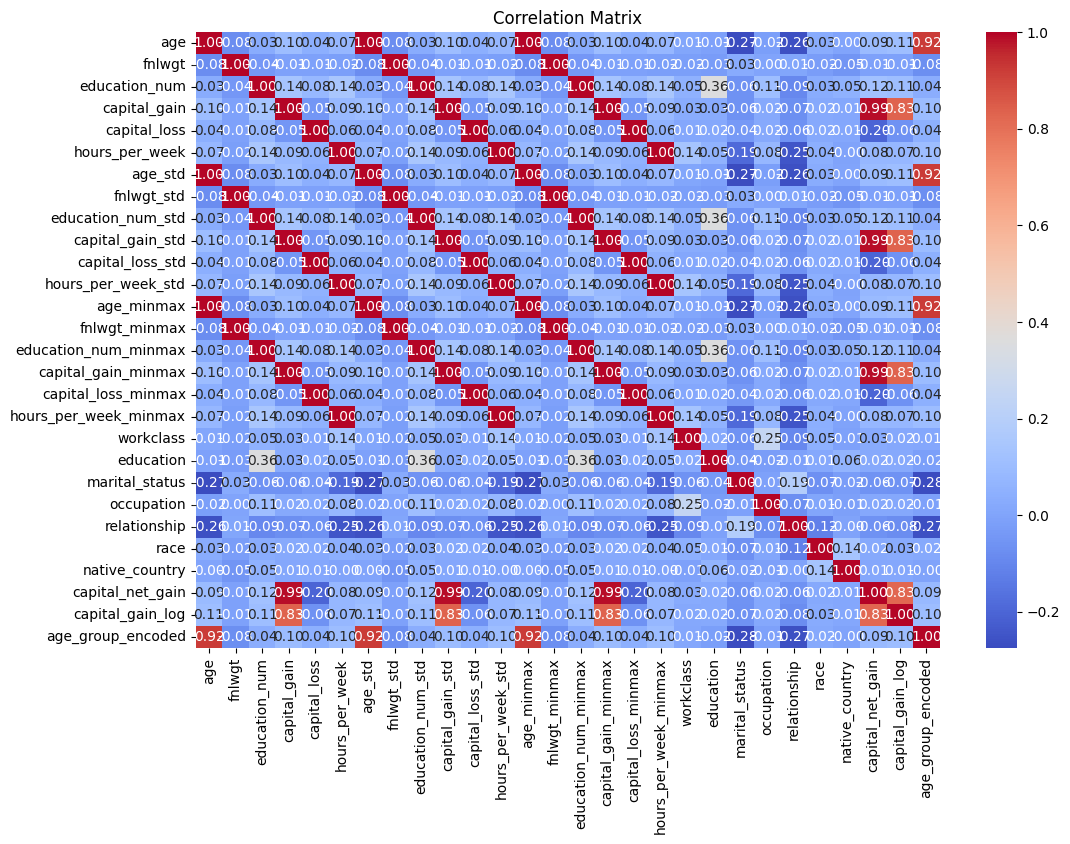

,x,y,ppscore,case,is_valid_score,metric,baseline_score,model_score,model
0,age,age,1.0,predict_itself,True,None,0.0000,1.0,None
306,capital_gain_std,capital_gain_std,1.0,predict_itself,True,None,0.0000,1.0,None
485,education_num_minmax,education,1.0,regression,True,mean absolute error,2.7102,0.0,DecisionTreeRegressor()
476,education_num_minmax,education_num_minmax,1.0,predict_itself,True,None,0.0000,1.0,None
464,education_num_minmax,education_num,1.0,regression,True,mean absolute error,1.8726,0.0,DecisionTreeRegressor()
442,fnlwgt_minmax,fnlwgt_minmax,1.0,predict_itself,True,None,0.0000,1.0,None
428,age_minmax,age_group_encoded,1.0,regression,True,mean absolute error,0.5196,0.0,DecisionTreeRegressor()
426,age_minmax,age_group,1.0,classification,True,weighted F1,0.3640,1.0,DecisionTreeClassifier()
408,age_minmax,age_minmax,1.0,predict_itself,True,None,0.0000,1.0,None
374,hours_per_week_std,hours_per_week_std,1.0,predict_itself,True,None,0.0000,1.0,None


In [ ]:
import ppscore as pps
import seaborn as sns
import matplotlib.pyplot as plt

# PPS Matrix
pps_matrix = pps.matrix(df_no_outliers)

# Pivot PPS for heatmap
pps_pivot = pps_matrix.pivot(index='x', columns='y', values='ppscore')

# Plot PPS Matrix
plt.figure(figsize=(12,8))
sns.heatmap(pps_pivot, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('PPS Matrix')
plt.show()

# Correlation Matrix
correlation_matrix = df_no_outliers.select_dtypes(include='number').corr()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



# Display top PPS scores
pps_matrix.sort_values(by='ppscore', ascending=False).head(10)


In [ ]:
!pip install ppscore


In [ ]:
# Install compatible versions
!pip install pandas==2.2.2 numpy==1.26.4
!pip install git+https://github.com/8080labs/ppscore.git  # Latest version from GitHub

# Then import
import pandas as pd
import numpy as np
import ppscore as pps


In [ ]:
!pip install numpy==1.26.4 pandas==2.2.2
!pip install git+https://github.com/8080labs/ppscore.git


In [ ]:
import pandas as pd
import numpy as np
import ppscore as pps


In [ ]:
"""In our analysis of the Adult dataset, we used Isolation Forest to detect and remove outliers based on numerical features like age, hours_per_week, capital_gain, and capital_loss. Here's how outliers can impact model performance :
1. Impact on Model Accuracy
Outliers can skew the learning process of machine learning models, especially:

Linear models (e.g., Logistic Regression): Outliers can disproportionately influence the decision boundary, reducing accuracy.

Distance-based models (e.g., KNN, KMeans): Outliers distort distance calculations, leading to poor clustering or classification.

In this dataset, extreme values in capital_gain and capital_loss might mislead the model into associating income with unrealistic financial behaviors.

2. Impact on Model Generalization
Outliers reduce the model's ability to generalize to unseen data because:

The model may overfit to extreme or rare data points.

Predictions for normal data become less reliable.

By removing outliers, we ensure that the model learns from patterns representative of the majority, improving its generalization.

3. Impact on Feature Relationships
During feature selection and correlation analysis:

Outliers inflate or deflate correlation coefficients.

This leads to misinterpretation of feature importance.

For example, without removing outliers, capital_gain might show an exaggerated correlation with income even if most people have zero gain."""



In [ ]:
"""Comparison Between PPS Matrix and Correlation Matrix
 1. Correlation Matrix
Measures the linear relationship between numeric variables.

Values range from -1 to +1:

+1: Perfect positive linear correlation

-1: Perfect negative linear correlation

0: No linear correlation

In our analysis, the correlation matrix showed:

capital_gain and income: moderately correlated

hours_per_week and income: weak correlation

Many features showed low correlations, suggesting that linear relationships are weak in this dataset.

2. Predictive Power Score (PPS) Matrix
Measures the predictive strength of any feature to predict another — works for both categorical and numerical data.

PPS ranges from 0 (no predictive power) to 1 (perfect prediction).

PPS can capture non-linear and asymmetric relationships, unlike correlation.

From our PPS analysis:

education_num → income had a higher PPS than seen in the correlation matrix.

marital_status → income showed predictive power not captured by correlation.

Some categorical features like relationship and occupation had non-zero PPS but low correlation because they are not numeric.
| Aspect            | Correlation Matrix                  | PPS Matrix                               |
| ----------------- | ----------------------------------- | ---------------------------------------- |
| Relationship Type | Only linear                         | Linear + Non-linear                      |
| Variable Types    | Numeric only                        | Numeric + Categorical                    |
| Symmetry          | Symmetric (X to Y = Y to X)         | Asymmetric (X → Y ≠ Y → X)               |
| Example Insight   | `capital_gain` linear with `income` | `education_num` predicts `income` better |
4. Conclusion
The correlation matrix provides a quick view of linear relationships but misses patterns between categorical and numeric variables.

The PPS matrix uncovered better predictors for income, including non-linear effects and categorical contributions.

Combining both gives a more comprehensive understanding of feature relationships, aiding in better feature selection and engineering."""
